In [2]:
#import library 
from urllib.parse import urlparse, parse_qs
from google_play_scraper import reviews, Sort
import pandas as pd

In [3]:
# Function to extract package name from Google Play URL
def get_package_name(play_store_url):
    parsed_url = urlparse(play_store_url)
    query_params = parse_qs(parsed_url.query)
    return query_params.get('id', [None])[0]

# Define Google Play Store URL
url = "https://play.google.com/store/apps/details?id=com.bca.mybca.omni.android&hl=id"

# Extract package name
package_name = get_package_name(url)
print("Extracted Package Name:", package_name)

Extracted Package Name: com.bca.mybca.omni.android


In [4]:
# Fetch reviews using the extracted package name
app_reviews, _ = reviews(
    package_name,
    lang='id',   # Language: Indonesian
    country='id',  # Country: Indonesian
    count=1000,   # Fetch 1000 reviews to allow filtering
    sort= Sort.NEWEST  # Get the latest reviews
)

# Convert reviews to a DataFrame
df = pd.DataFrame(app_reviews)

# Display
df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,521913e4-c7b1-46be-8242-9ced919156a3,Bima Bimbim,https://play-lh.googleusercontent.com/a/ACg8oc...,buruk,1,0,NaN,2026-06-20 20:21:21,"Mohon maaf atas ketidaknyamanan Bapak/Ibu, moh...",2026-06-20 20:25:53,NaN
1,4f81924b-e06e-491d-9872-865fc5b6c78b,Baim Setiya Hesya,https://play-lh.googleusercontent.com/a/ACg8oc...,Amit-amit ni aplikasi Verifikasi wajah ribet b...,2,0,2.18.0,2026-06-20 20:14:18,"Mohon maaf atas kendala yang Bapak/Ibu alami, ...",2026-06-20 20:31:41,2.18.0
2,29c07bdc-1d0b-455b-8170-5ccc3d766989,206 RIZKI ILHAM PRATAMA,https://play-lh.googleusercontent.com/a-/ALV-U...,ini apaan sih setiap kali pasti ada gangguan. ...,1,0,2.18.0,2026-06-20 20:02:30,Mohon maaf atas ketidaknyamanannya. Sebelumnya...,2026-06-20 20:30:11,2.18.0
3,53d5a360-e0c4-4a40-a6d5-d182294b2a7b,Desiarianti Desi,https://play-lh.googleusercontent.com/a-/ALV-U...,sangat puas,5,0,NaN,2026-06-20 19:42:01,Terima kasih atas ulasannya. Semoga aplikasi m...,2026-06-20 20:25:10,NaN
4,35e8d31c-7783-4444-beb2-82eb4d4b1a76,Iis Wardana,https://play-lh.googleusercontent.com/a-/ALV-U...,the best pokoknya mah,5,0,NaN,2026-06-20 19:39:14,Terima kasih atas ulasannya. Semoga aplikasi m...,2026-06-20 20:24:20,NaN
...,...,...,...,...,...,...,...,...,...,...,...
995,aef7adbc-77fe-40e7-b3a6-786af5adbe68,Taufik Hidayat,https://play-lh.googleusercontent.com/a-/ALV-U...,parah. tidak bisa setor tunai cardless di atm ...,5,0,NaN,2026-05-24 10:41:03,"Mohon maaf atas ketidaknyamanan Bapak/Ibu, moh...",2026-05-24 12:56:31,NaN
996,e7b239c7-0fdb-4868-b0bd-9bf8cf094c32,rezky ana halim,https://play-lh.googleusercontent.com/a/ACg8oc...,"Ini ko gabisa di update ya, katanya aplikasi s...",2,0,2.13.0,2026-05-24 08:46:57,"Mohon maaf atas ketidaknyamanan Bapak/Ibu, aks...",2026-05-24 09:37:45,2.13.0
997,1ce289a0-0f2c-4d48-8800-21bfe85b51c9,she fadhila,https://play-lh.googleusercontent.com/a/ACg8oc...,👍👍👍👍👍,5,0,2.17.1,2026-05-24 08:27:38,Terima kasih atas ulasannya. Semoga aplikasi m...,2026-05-24 09:37:08,2.17.1
998,c0b02409-e2e9-4bcc-bb58-5c7b905a4a4e,GALIH RAKASIWI,https://play-lh.googleusercontent.com/a-/ALV-U...,"Lah myBCA jadi gak bisa di buka sih , harus hu...",1,0,2.13.0,2026-05-24 08:21:20,Mohon maaf atas kendala yang Bapak/Ibu alami. ...,2026-05-24 08:25:56,2.13.0


In [5]:
# Select only the required columns: 'reviewId', 'content', and 'score'
df_filtered_columns = df[['reviewId', 'content', 'score']]

# Display the result
df_filtered_columns

,reviewId,content,score
0,521913e4-c7b1-46be-8242-9ced919156a3,buruk,1
1,4f81924b-e06e-491d-9872-865fc5b6c78b,Amit-amit ni aplikasi Verifikasi wajah ribet b...,2
2,29c07bdc-1d0b-455b-8170-5ccc3d766989,ini apaan sih setiap kali pasti ada gangguan. ...,1
3,53d5a360-e0c4-4a40-a6d5-d182294b2a7b,sangat puas,5
4,35e8d31c-7783-4444-beb2-82eb4d4b1a76,the best pokoknya mah,5
...,...,...,...
995,aef7adbc-77fe-40e7-b3a6-786af5adbe68,parah. tidak bisa setor tunai cardless di atm ...,5
996,e7b239c7-0fdb-4868-b0bd-9bf8cf094c32,"Ini ko gabisa di update ya, katanya aplikasi s...",2
997,1ce289a0-0f2c-4d48-8800-21bfe85b51c9,👍👍👍👍👍,5
998,c0b02409-e2e9-4bcc-bb58-5c7b905a4a4e,"Lah myBCA jadi gak bisa di buka sih , harus hu...",1


In [6]:
import re
import nltk
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

nltk.download('stopwords')

# Stopwords Indonesia
stop_words = set(stopwords.words('indonesian'))

for word in ['tidak', 'kurang', 'bukan', 'belum', 'jangan']:
    stop_words.discard(word)
# Custom stopwords
custom_stopwords = {
    'nya',
    'ga',
    'gak',
    'aja',
    'lot',
    'ya',
    'yg',
    'banget',
    'udah',
    'gk',
    'my'
}

stop_words.update(custom_stopwords)

# Stopwords tambahan setelah stemming
post_stem_stopwords = {
    'lot'
}

# Stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def preprocess_text(text):

    if not isinstance(text, str):
        return ""

    text = text.lower()

    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    text = re.sub(r'[^\w\s]', ' ', text)

    text = re.sub(r'\d+', '', text)

    words = text.split()

    # Hapus stopwords sebelum stemming
    words = [
        word for word in words
        if word not in stop_words and len(word) > 1
    ]

    # Stemming
    words = [stemmer.stem(word) for word in words]

    # Hapus stopwords setelah stemming
    words = [
        word for word in words
        if word not in post_stem_stopwords
    ]

    return ' '.join(words)

# Terapkan preprocessing
df_filtered_columns = df_filtered_columns.copy()

df_filtered_columns['cleaned_text'] = (
    df_filtered_columns['content']
    .apply(preprocess_text)
)

output_df = df_filtered_columns[['content', 'cleaned_text']]
output_df.head(10)

[nltk_data] Downloading package stopwords to C:\Users\Michael
[nltk_data]     Zidane\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,content,cleaned_text
0,buruk,buruk
1,Amit-amit ni aplikasi Verifikasi wajah ribet b...,amit amit ni aplikasi verifikasi wajah ribet b...
2,ini apaan sih setiap kali pasti ada gangguan. ...,sih kali ganggu belanja pake qris mudah tbtb a...
3,sangat puas,puas
4,the best pokoknya mah,the best pokok mah
5,bagus,bagus
6,top,top
7,saya tidak ada keluar akun sama sekali tapi wa...,tidak akun buka dah log out pas nyoba login lg...
8,"kok kode otp dari BCA blm terkirim,pdahal saya...",kode otp bca blm kirim pdahal sdah isi pulsa t...
9,"uang gue ketahan gara"" lu eror mulu",uang gue tahan gara lu eror mulu


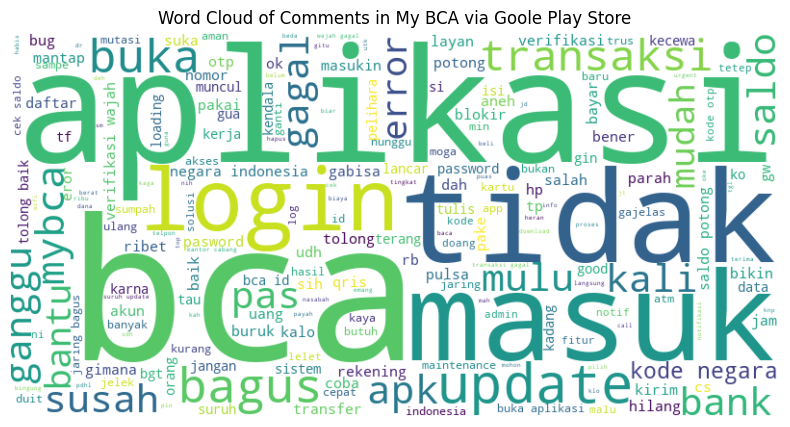

In [7]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all cleaned text into a single string for the word cloud
all_text = ' '.join(output_df['cleaned_text'])

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Comments in My BCA via Goole Play Store")
plt.show()

           Word  Frequency
78          bca        191
3      aplikasi        169
58        tidak        135
175       masuk        126
122      update        122
66        login        120
44        bagus         97
60         buka         86
145       saldo         83
210   transaksi         73
176       gagal         66
4    verifikasi         65
76         kode         55
181       mybca         52
207         apk         52
5         wajah         52
118       susah         50
393      potong         50
34       ganggu         50
49         bank         49


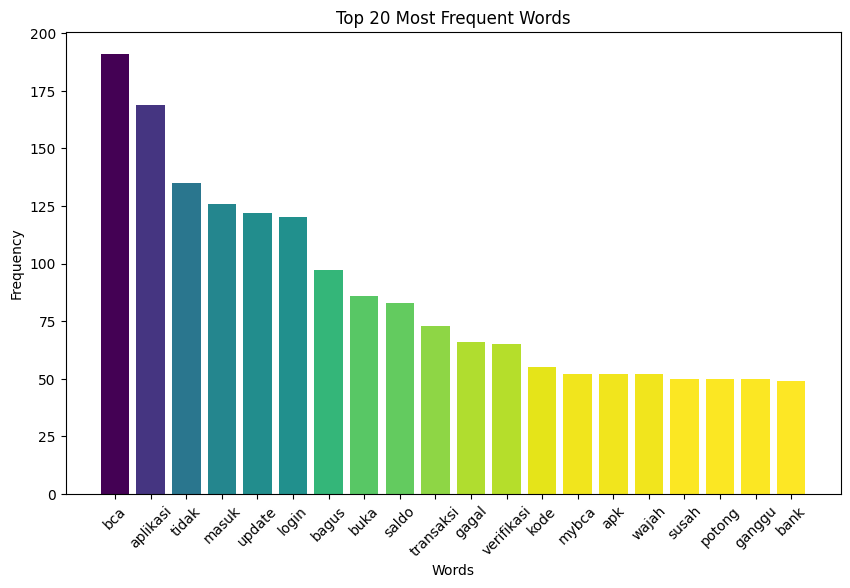

In [8]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import viridis_r
from matplotlib.colors import Normalize


# split all cleaned text into individual words
all_words = ' '.join(output_df['cleaned_text']).split()

# Count the frequency of each word
word_counts = Counter(all_words)

# Convert the counts to a DataFrame for easier analysis
word_freq_df = pd.DataFrame(word_counts.items(), columns=['Word', 'Frequency']).sort_values(by='Frequency', ascending=False)

# Display the top 20 most frequent words
print(word_freq_df.head(20))

# Prepare inverted viridis colormap
top_words = word_freq_df.head(20)
norm = Normalize(vmin=min(top_words['Frequency']), vmax=max(top_words['Frequency']))
colors = [viridis_r(norm(value)) for value in top_words['Frequency']]

# Show a bar plot of the top 20 most frequent words with inverted viridis
plt.figure(figsize=(10, 6))
plt.bar(top_words['Word'], top_words['Frequency'], color=colors)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 20 Most Frequent Words')
plt.xticks(rotation=45)
plt.show()



In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=False,
    use_idf=True,
    norm='l2',
    smooth_idf=True
)

tfidf_matrix = tfidf.fit_transform(output_df['cleaned_text'])

print(tfidf_matrix.shape)

(1000, 1685)


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Membuat kolom label 'sentiment' berdasarkan 'score'
df_filtered_columns['sentiment'] = df_filtered_columns['score'].apply(lambda x: 1 if x > 3 else 0)

# 2. Inisialisasi TF-IDF Vectorizer (menggunakan default tokenizer)
tfidf = TfidfVectorizer(strip_accents=None,
                        lowercase=False,
                        use_idf=True,
                        norm='l2',
                        smooth_idf=True)

# 3. Transformasi teks yang sudah dibersihkan (cleaned_text) menjadi matriks fitur (X)
X = tfidf.fit_transform(df_filtered_columns['cleaned_text'])

# 4. Target variabel (Y)
y = df_filtered_columns['sentiment']

print("Dimensi fitur X:", X.shape)
print("Dimensi target y:", y.shape)

Dimensi fitur X: (1000, 1685)
Dimensi target y: (1000,)


In [11]:
from sklearn.model_selection import train_test_split

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data training: {X_train.shape[0]}")
print(f"Jumlah data testing: {X_test.shape[0]}")

Jumlah data training: 800
Jumlah data testing: 200


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Inisialisasi model Logistic Regression
model = LogisticRegression()

# 2. Melatih (Training) model menggunakan data train
model.fit(X_train, y_train)

# 3. Memprediksi data test
y_pred = model.predict(X_test)

# 4. Menghitung dan menampilkan Akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {accuracy * 100:.2f}%\n")

# Menampilkan laporan klasifikasi lengkap
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Akurasi Model: 83.50%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.80      1.00      0.89       133
    Positive       1.00      0.51      0.67        67

    accuracy                           0.83       200
   macro avg       0.90      0.75      0.78       200
weighted avg       0.87      0.83      0.82       200



In [13]:
def predict_sentiment(text):
    # Preprocess teks menggunakan fungsi 'preprocess_text' yang sudah kamu buat di awal
    cleaned_input = preprocess_text(text)

    # Ubah teks ke dalam format TF-IDF
    vectorized_input = tfidf.transform([cleaned_input])

    # Lakukan prediksi
    prediction = model.predict(vectorized_input)

    # Kembalikan hasil berupa string
    return "Positive" if prediction[0] == 1 else "Negative"

# Mari kita uji dengan kalimat baru!
test_sentence_1 = "Aplikasi sangat bagus dengan tampilan interface yang menarik dan mempunyai banyak fitur"
test_sentence_2 = "Sangat berat tidak cocok untuk dijalankan di smartphone saya,saran perbaiki sistemnya"

print(f"Review: '{test_sentence_1}'\nPrediksi: {predict_sentiment(test_sentence_1)}\n")
print(f"Review: '{test_sentence_2}'\nPrediksi: {predict_sentiment(test_sentence_2)}")

Review: 'Aplikasi sangat bagus dengan tampilan interface yang menarik dan mempunyai banyak fitur'
Prediksi: Positive

Review: 'Sangat berat tidak cocok untuk dijalankan di smartphone saya,saran perbaiki sistemnya'
Prediksi: Negative


In [14]:
# Prediksi seluruh data matriks TF-IDF (X)
all_predictions = model.predict(X)

# Masukkan hasil prediksi ke dalam dataframe
df_filtered_columns['predicted_sentiment'] = all_predictions

# Mapping angka (1, 0) kembali menjadi teks agar mudah dibaca pada grafik nanti
df_filtered_columns['sentiment_label'] = df_filtered_columns['predicted_sentiment'].map({1: 'Positive', 0: 'Negative'})

# Tampilkan 5 baris pertama untuk mengecek hasilnya
df_filtered_columns[['content', 'score', 'sentiment_label']].head()

,content,score,sentiment_label
0,buruk,1,Negative
1,Amit-amit ni aplikasi Verifikasi wajah ribet b...,2,Negative
2,ini apaan sih setiap kali pasti ada gangguan. ...,1,Negative
3,sangat puas,5,Positive
4,the best pokoknya mah,5,Positive


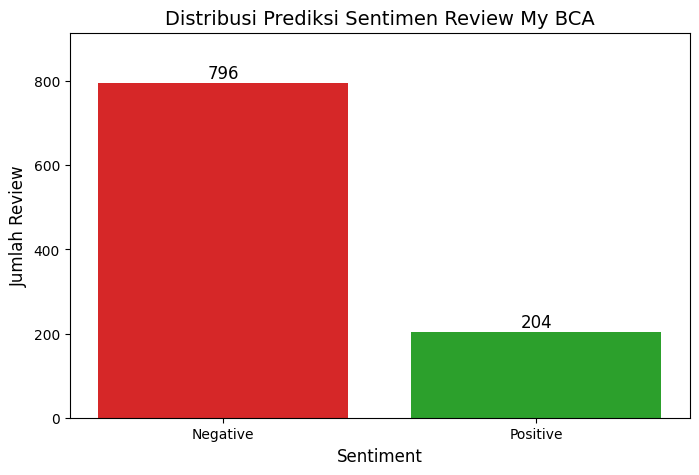

In [15]:
import matplotlib.pyplot as plt

# Hitung jumlah masing-masing sentimen
sentiment_counts = df_filtered_columns['sentiment_label'].value_counts()

# Membuat Bar Chart
plt.figure(figsize=(8, 5))
bars = plt.bar(sentiment_counts.index, sentiment_counts.values, color=[ '#d62728','#2ca02c']) # Hijau & Merah

# Menambahkan judul dan label sumbu
plt.title('Distribusi Prediksi Sentimen Review My BCA', fontsize=14)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Jumlah Review', fontsize=12)

# Menambahkan angka (label) di atas setiap bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom', fontsize=12)

# Tampilkan grafik
plt.ylim(0, max(sentiment_counts.values) + max(sentiment_counts.values)*0.15) # Memberi ruang kosong di atas bar

plt.show()



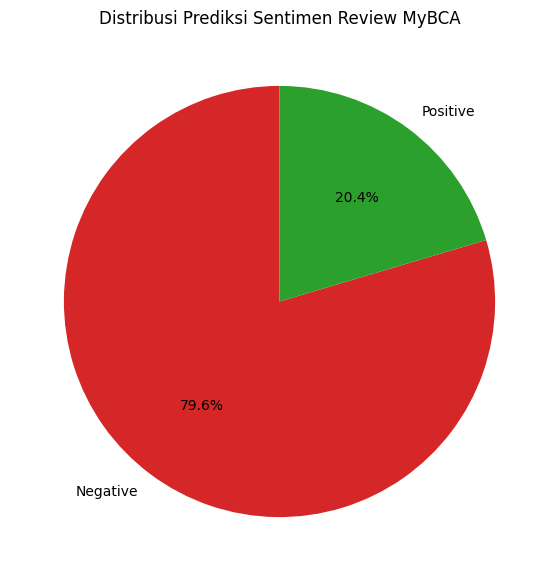

In [16]:
import matplotlib.pyplot as plt

# Hitung jumlah masing-masing sentimen
sentiment_counts = df_filtered_columns['sentiment_label'].value_counts()

# Warna: Positive = Hijau, Negative = Merah
color_map = {
    'Positive': '#2ca02c',
    'Negative': '#d62728'
}

colors = [color_map[label] for label in sentiment_counts.index]

plt.figure(figsize=(7,7))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)

plt.title('Distribusi Prediksi Sentimen Review MyBCA')

plt.show()

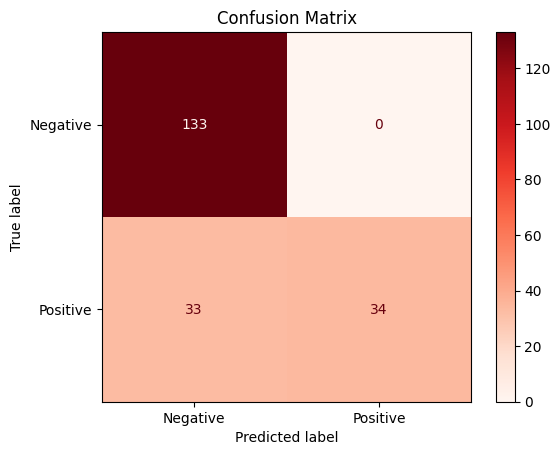

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative', 'Positive']
)

disp.plot(cmap='Reds')
plt.title('Confusion Matrix')
plt.show()

In [18]:
# Data hasil scraping
df_filtered_columns.to_csv("data_scraping.csv", index=False)

# Data setelah cleaning
output_df.to_csv("data_cleaning.csv", index=False)

# Data hasil sentimen
df_filtered_columns[['content','score','sentiment_label']].to_csv(
    "hasil_sentimen.csv",
    index=False
)

In [19]:
import joblib

joblib.dump(model, 'model.pkl')
joblib.dump(tfidf, 'tfidf.pkl')

['tfidf.pkl']

In [20]:
df_filtered_columns.to_csv(
    "mybca_reviews_final.csv",
    index=False
)

In [21]:
df_filtered_columns['sentiment_label'].value_counts()

sentiment_label
Negative    796
Positive    204
Name: count, dtype: int64

In [22]:
print(f"Akurasi Model: {accuracy * 100:.2f}%")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Akurasi Model: 83.50%
              precision    recall  f1-score   support

    Negative       0.80      1.00      0.89       133
    Positive       1.00      0.51      0.67        67

    accuracy                           0.83       200
   macro avg       0.90      0.75      0.78       200
weighted avg       0.87      0.83      0.82       200

